# Notebook 2C — Tuning a Neural Network

*Day 4 · Student C's tuning lab — read the docstring, choose knobs, search, log, and save your MLP.*

In [1]:
# ======================================================================================
# Setup — run this first (you don't need to read it closely).
# It imports a few libraries, sets a shared plot style, and defines the helper functions used
# throughout the notebook (load_data, the plot helpers, the metric helpers, ...).  These are the
# SAME helpers in every notebook, so your results line up with your teammates'.  If a later cell
# says a helper is "not defined", you probably skipped this cell — run it, then carry on.
# ======================================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------
# Paths — resolved so the notebooks work whether they're run from the materials folder or
# from solutions/ .  Outputs and figures always land in the materials root.
# ----------------------------------------------------------------------------------------
def _materials_root():
    """Folder that contains data/ ; searched upward from the working directory."""
    here = os.path.abspath(os.getcwd())
    for d in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        if os.path.isdir(os.path.join(d, "data")):
            return d
    return here

ROOT = _materials_root()
DATA_DIR = os.path.join(ROOT, "data")
OUTPUTS_DIR = os.path.join(ROOT, "outputs")
FIGURES_DIR = os.path.join(ROOT, "figures")
MODELS_DIR = os.path.join(ROOT, "models")     # fitted models saved to disk (experiment tracking)
for _d in (DATA_DIR, OUTPUTS_DIR, FIGURES_DIR, MODELS_DIR):
    os.makedirs(_d, exist_ok=True)

# Module-level cache of the reconstruction basis (set by load_data; used by reconstruct_spectrum).
_RECON = {"wavelength": None, "basis": None, "is_mock": True, "Xerr": None}
_RAW_CACHE = {}   # path -> full arrays, so repeated load_data() calls don't re-read the file

# Default working-set size.  The real catalog is ~200k stars; we train on a fast deterministic
# subsample by default so in-class fits stay quick AND every notebook sees the SAME stars (which
# keeps the NB2->NB3->NB4 saved-prediction hand-off aligned).  Pass n=None to use the WHOLE
# high-quality catalog (the "does more data help?" / label-transfer-at-scale exercise).
DEFAULT_N = 30000

# Canonical label columns.  The modelling track predicts [Fe/H]; Teff & logg are explored and
# used as the axes for residual / coverage maps.  alpha/age/dist are extra "explore" labels.
LABEL_COLS = ["Teff", "logg", "FeH", "alpha", "age", "dist"]
PRETTY = {"Teff": r"$T_\mathrm{eff}$ [K]", "logg": r"$\log g$ [dex]",
          "FeH": r"[Fe/H] [dex]", "alpha": r"[$\alpha$/M] [dex]",
          "age": "age [Gyr]", "dist": "distance [pc]"}


# ========================================================================================
# Plot style
# ========================================================================================
def set_plot_style():
    """Consistent, readable matplotlib defaults.  Called once in setup."""
    plt.rcParams.update({
        "figure.figsize": (6.4, 4.4), "figure.dpi": 110, "savefig.dpi": 150,
        "savefig.bbox": "tight", "font.size": 12, "axes.titlesize": 13,
        "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.25,
        "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
        "legend.frameon": False, "legend.fontsize": 11, "lines.linewidth": 2.0,
        "scatter.edgecolors": "none", "image.cmap": "viridis",
    })

# A small colour-blind-friendly palette used across the materials for named series.
COLORS = {"linear": "#888888", "knn": "#0072B2", "rf": "#009E73",
          "nn": "#D55E00", "native": "#0072B2", "conformal": "#D55E00",
          "truth": "#222222", "accent": "#CC79A7"}


# ========================================================================================
# Data loading  (the mock generator lives here so the shipped npz and the on-the-fly
# fallback are guaranteed identical)
# ========================================================================================
_C2_NM = 1.438777e7  # second radiation constant hc/k in nm*K


def _build_basis(wave_min=336.0, wave_max=1020.0, n_wave=343, n_bp=55, n_rp=55):
    """Smooth windowed-cosine modes per band, orthonormalised.  Low modes are broad
    (continuum), high modes wiggly (fine structure).  reconstruct = B @ coeff."""
    wave = np.linspace(wave_min, wave_max, n_wave)
    cols = []
    def band(lo, hi, n_modes):
        x = (wave - lo) / (hi - lo)
        win = np.where((x >= 0) & (x <= 1), np.sin(np.clip(x, 0, 1) * np.pi) ** 0.5, 0.0)
        for j in range(n_modes):
            cols.append(np.cos(j * np.pi * np.clip(x, 0, 1)) * win)
    band(wave_min, 690.0, n_bp)
    band(630.0, wave_max, n_rp)
    Q, _ = np.linalg.qr(np.column_stack(cols))
    return wave, Q[:, :n_bp + n_rp]


def _synthesize_mock(n=50000, seed=42):
    """
    # MOCK DATA — swap for the real Zenodo loader.
    Physically-motivated synthetic stand-in for the Laroche & Speagle APOGEE x Gaia-XP
    cross-match.  Returns the same dict that the shipped npz stores.  See the build spec
    and _build/make_mock_dataset.py for the full rationale.  In one sentence: a Planck
    continuum sets Teff; Balmer lines reinforce Teff; gravity-sensitive molecular bands
    carry log g; SHALLOW metal lines (suppressed at high Teff) carry the hard, heteroscedastic
    [Fe/H]; reddening + hidden factors add a realistic irreducible (aleatoric) floor.
    """
    rng = np.random.default_rng(seed)
    wave, B = _build_basis()
    W = wave.size

    # --- labels with Kiel-diagram structure: dwarfs + giants + red clump + metal-poor halo ---
    is_giant = rng.random(n) < 0.45
    Teff = np.empty(n); logg = np.empty(n); FeH = np.empty(n)
    nd, ng = np.count_nonzero(~is_giant), np.count_nonzero(is_giant)
    Td = 4000 + 3100 * rng.beta(1.5, 2.5, nd)
    Teff[~is_giant] = Td
    logg[~is_giant] = 4.62 - 0.00013 * (Td - 4500) + rng.normal(0, 0.10, nd)
    FeH[~is_giant] = rng.normal(-0.05, 0.25, nd)
    Tg = 3800 + 1700 * rng.beta(2.0, 2.3, ng)
    Teff[is_giant] = Tg
    logg[is_giant] = 1.7 + 0.00095 * (Tg - 3800) + rng.normal(0, 0.33, ng)
    FeH[is_giant] = rng.normal(-0.28, 0.34, ng)
    clump = is_giant & (rng.random(n) < 0.33); nc = np.count_nonzero(clump)
    Teff[clump] = rng.normal(4800, 140, nc); logg[clump] = rng.normal(2.45, 0.11, nc)
    FeH[clump] = rng.normal(-0.10, 0.20, nc)
    halo = rng.random(n) < 0.06; nh = np.count_nonzero(halo)
    Teff[halo] = rng.normal(4900, 450, nh)
    logg[halo] = np.clip(rng.normal(2.2, 0.7, nh), 0.5, 3.6)
    FeH[halo] = rng.normal(-1.45, 0.45, nh)
    is_giant = is_giant | halo
    Teff = np.clip(Teff, 3500, 7600); logg = np.clip(logg, 0.3, 5.0); FeH = np.clip(FeH, -2.4, 0.55)
    alpha = np.clip(0.13 - 0.24 * FeH + rng.normal(0, 0.035, n), -0.05, 0.5)
    age = np.clip(2.0 + 6.5 * is_giant - 3.5 * FeH + rng.normal(0, 1.8, n), 0.3, 13.5)
    dist = np.exp(rng.normal(6.7, 0.9, n)) * (1.0 + 1.5 * is_giant)

    # --- forward model: labels -> flux ---
    def gauss(c, w): return np.exp(-0.5 * ((wave - c) / w) ** 2)
    x = _C2_NM / (wave[None, :] * Teff[:, None])
    flux = wave[None, :] ** -5 / np.expm1(np.clip(x, 1e-6, 700))
    flux = flux / flux.mean(axis=1, keepdims=True)
    jump = 1.0 / (1.0 + np.exp((wave - 382.0) / 6.0))
    flux *= 1.0 - (0.18 * np.clip((Teff - 5200) / 2500, 0, 1.4) * (1 + 0.15 * (4.5 - logg)))[:, None] * jump[None, :]
    balmer = sum(a * gauss(c, 9.0) for c, a in [(434., .9), (486.1, 1.1), (656.3, 1.)])
    bstr = np.clip(np.exp((Teff - 5200) / 1500), 0.15, 6.0) * (1 + 0.12 * (4.5 - logg))
    flux *= 1.0 - 0.012 * bstr[:, None] * balmer[None, :]
    g_dwarf = np.clip(logg - 3.0, 0, 2.0)[:, None]; g_giant = np.clip(3.6 - logg, 0, 3.2)[:, None]
    coolf = np.clip((5500 - Teff) / 2000.0, 0.2, 1.4)[:, None]
    grav = np.zeros((n, W))
    for c, a in [(488., 1.), (521., .9), (692., .8)]: grav += a * g_dwarf * gauss(c, 15.)[None, :]
    for c, a in [(421., .9), (793., .8), (883., 1.)]: grav += a * g_giant * gauss(c, 17.)[None, :]
    flux *= 1.0 - 0.038 * coolf * grav
    metal = sum(a * gauss(c, 11.0) for c, a in
                [(422.7, 1.), (460., .7), (517.3, 1.2), (527., .9), (589.3, 1.1),
                 (670.8, .6), (770., .6), (850., .8), (920., .5)])
    # Line depth scales with metal abundance (metal-poor stars have WEAK lines -> little [Fe/H]
    # information -> the dominant, physically-correct source of heteroscedastic [Fe/H] error).
    # Temperature only mildly suppresses lines; gravity gives luminous giants slightly weaker,
    # more variable lines (they are also the sparsest, most-extrapolated regime).
    mstr = 10.0 ** (0.55 * FeH)
    tsupp = np.clip(np.exp(-(Teff - 4500) / 4800.0), 0.6, 1.25)
    line_amp = (mstr * tsupp * np.clip(0.7 + 0.22 * logg, 0.7, 1.4))[:, None]
    flux *= 1.0 - 0.045 * line_amp * metal[None, :]
    ebv = np.abs(rng.normal(0, 0.11, n))[:, None]
    ext = (550.0 / wave) ** 1.0
    flux *= 10.0 ** (-0.4 * 1.6 * ebv * (ext / ext.mean())[None, :])
    P = np.column_stack([np.sin(f * np.pi * (wave - wave[0]) / (wave[-1] - wave[0])) for f in (1.5, 3.5, 6.5)])
    flux *= 1.0 + 0.004 * (rng.normal(0, 1, (n, 3)) @ P.T)
    gflux = np.exp(rng.normal(0.0, 0.8, n))
    snr = np.clip(58 * gflux ** 0.30 * np.exp(rng.normal(0, 0.30, n)), 20, 400)
    obs = gflux[:, None] * np.clip(flux, 1e-3, None)
    noise_std = obs.mean(axis=1, keepdims=True) / snr[:, None]        # photon-noise std (per star)
    obs = obs + rng.normal(0, 1, obs.shape) * noise_std
    X = (obs @ B).astype(np.float32)
    # per-coefficient measurement error on the RAW coefficients (the orthonormal basis preserves the
    # per-component noise std) — used by the NB3 input-Monte-Carlo stretch.
    Xerr = np.repeat(noise_std, 110, axis=1).astype(np.float32)
    return dict(X=X, Xerr=Xerr, Teff=Teff, logg=logg, FeH=FeH, alpha=alpha, age=age, dist=dist,
                snr=snr, gflux=gflux, source_id=(1_000_000_000 + np.arange(n)),
                wavelength=wave, basis=B.astype(np.float32), is_mock=True)


def load_data(path=None, n=DEFAULT_N, seed=0, verbose=True):
    """
    Load the dataset in one line:  X, y, meta = load_data()

    Parameters
    ----------
    n    : working-set size.  Returns a deterministic random subsample of `n` stars (default
           DEFAULT_N=30000) so fits are fast and every notebook sees the same stars.  Pass
           `n=None` to use the ENTIRE high-quality catalog (the scale-up exercise) — slower.
    seed : seed for the subsample (keep it fixed so the NB2->NB3->NB4 hand-off stays aligned).

    Returns
    -------
    X    : float array, shape (n, 110) — the Gaia XP coefficients (55 BP + 55 RP).
    y    : DataFrame with columns Teff, logg, FeH (+ alpha, dist) — the labels.
    meta : DataFrame with source_id, snr, gflux — per-star bookkeeping (gflux is the
           brightness scale used by normalize_by_g).
    """
    if path is None:
        for cand in ("xp_apogee_real.npz", "xp_apogee_mock.npz"):
            p = os.path.join(DATA_DIR, cand)
            if os.path.exists(p):
                path = p
                break
    key = path if path is not None else "__synth__"
    if key in _RAW_CACHE:
        data = _RAW_CACHE[key]
    elif path is not None and os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        data = {k: d[k] for k in d.files}
        _RAW_CACHE[key] = data
    else:
        if verbose:
            print("No data file found — synthesising the mock dataset on the fly.")
        data = _synthesize_mock()
        _RAW_CACHE[key] = data
    is_mock = bool(data.get("is_mock", True))
    src = os.path.basename(path) if path else "synthesised mock"

    _RECON["wavelength"] = np.asarray(data["wavelength"], float)
    _RECON["basis"] = np.asarray(data["basis"], float)
    _RECON["is_mock"] = is_mock

    X_all = np.asarray(data["X"], dtype=float)
    N = X_all.shape[0]
    if n is not None and n < N:
        sel = np.sort(np.random.default_rng(seed).permutation(N)[:n])
    else:
        sel = np.arange(N)
    X = X_all[sel]
    _RECON["Xerr"] = np.asarray(data["Xerr"], float)[sel] if "Xerr" in data else None  # for input-MC (NB3)
    y = pd.DataFrame({c: np.asarray(data[c], float)[sel] for c in LABEL_COLS if c in data})
    meta = pd.DataFrame({k: np.asarray(data[k]).ravel()[sel] for k in ("source_id", "snr", "gflux") if k in data})
    if verbose:
        tag = "MOCK (synthetic)" if is_mock else "REAL (Gaia XP x APOGEE)"
        extra = f" (subsampled from {N:,}; pass n=None for all)" if len(sel) < N else ""
        print(f"Loaded {src}: {tag}  —  {X.shape[0]:,} stars{extra}, {X.shape[1]} coefficients.")
    return X, y, meta


# ========================================================================================
# Spectrum reconstruction
# ========================================================================================
def load_input_errors():
    """Per-coefficient measurement errors for the stars from the LAST `load_data()` call (same rows,
    same order, same (n, 110) shape as the `X` you just loaded) — on the RAW coefficient scale.
    For the NB3 input-Monte-Carlo stretch:  X_perturbed = X + rng.normal(0, load_input_errors()).
    Returns None if the dataset has no stored errors (call `load_data()` first)."""
    if _RECON["Xerr"] is None:
        load_data(verbose=False)
    return _RECON["Xerr"]


def reconstruct_spectrum(coeffs):
    """
    Turn a star's 110 XP coefficients into a sampled spectrum: returns (wavelength_nm, flux).
    Accepts a single (110,) vector or an (M, 110) batch.

    On the shipped data this uses the stored smooth basis (B @ coeff) — no extra packages.

    # REAL DATA: with the genuine Gaia archive continuous representation you would instead
    # reconstruct with GaiaXPy, e.g.:
    #     from gaiaxpy import calibrate
    #     sampling = np.arange(336, 1021, 2.0)              # nm
    #     spectra, sampled_wl = calibrate(source_dataframe, sampling=sampling, save_file=False)
    # The stored basis is recovered from Zenodo's wavelength-space spectra at curation time
    # (see _build/prepare_real_data.py), so this helper stays identical for mock and real.
    """
    if _RECON["basis"] is None:
        load_data(verbose=False)
    B, wave = _RECON["basis"], _RECON["wavelength"]
    coeffs = np.asarray(coeffs, float)
    flux = coeffs @ B.T
    return wave, flux


# ========================================================================================
# Preprocessing recipe:  normalize by the G-band  ->  standardize (fit on train only)
# ========================================================================================
def normalize_by_g(X, g):
    """Divide each star's coefficients by its G-band brightness scale `g` (a column of meta).
    Removes brightness/distance and keeps the spectral SHAPE — what carries the labels."""
    g = np.asarray(g, float).reshape(-1, 1)
    return np.asarray(X, float) / g


def standardize(X_train, X_other):
    """Z-score the coefficients using statistics from the TRAINING set only, then apply the
    same shift/scale to another split.  Returns (X_train_scaled, X_other_scaled).
    (Equivalent to sklearn's StandardScaler fit on train; spelled out for clarity.)"""
    mu = X_train.mean(axis=0, keepdims=True)
    sd = X_train.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return (X_train - mu) / sd, (X_other - mu) / sd


# ========================================================================================
# Splitting  (fixed seed so every student gets the same train / cal / test stars)
# ========================================================================================
def train_cal_test_split(X, y, seed=0, fracs=(0.6, 0.2, 0.2)):
    """Reproducible 60/20/20 split into train / calibration / test.
    Returns a dict with X_* arrays, y_* DataFrames, and idx_* index arrays.
    Calibration is held out for the uncertainty work in NB3/NB4."""
    X = np.asarray(X, float)
    y = y.reset_index(drop=True)
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_tr = int(fracs[0] * n); n_ca = int(fracs[1] * n)
    i_tr, i_ca, i_te = idx[:n_tr], idx[n_tr:n_tr + n_ca], idx[n_tr + n_ca:]
    return {
        "X_train": X[i_tr], "X_cal": X[i_ca], "X_test": X[i_te],
        "y_train": y.iloc[i_tr].reset_index(drop=True),
        "y_cal": y.iloc[i_ca].reset_index(drop=True),
        "y_test": y.iloc[i_te].reset_index(drop=True),
        "idx_train": i_tr, "idx_cal": i_ca, "idx_test": i_te,
    }


# ========================================================================================
# Models — the four estimators the students compare.  Defined ONCE here so NB2, NB3 and NB4
# build byte-identical models, which is what lets predictions and intervals line up across
# notebooks and across the three students.  Each is a Pipeline(StandardScaler + estimator),
# so you feed it the G-normalized coefficients and it standardizes internally (fit on train).
# ========================================================================================
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

MODEL_NAMES = {"linear": "Linear regression (baseline)", "knn": "K-nearest neighbors",
               "rf": "Random forest", "nn": "Neural network (MLP)"}

def make_model(name, **overrides):
    """Canonical Pipeline(StandardScaler + estimator) for a model name in {linear,knn,rf,nn}.
    Pass overrides to tune one knob, e.g. make_model('knn', n_neighbors=20).  The step name for
    the estimator is its lowercased class name (e.g. 'kneighborsregressor') — handy in NB3 when
    you reach inside the fitted pipeline for a model-native uncertainty."""
    if name == "linear":
        est = LinearRegression(**overrides)
    elif name == "knn":
        est = KNeighborsRegressor(**{"n_neighbors": 12, **overrides})
    elif name == "rf":
        est = RandomForestRegressor(**{"n_estimators": 150, "min_samples_leaf": 3,
                                       "random_state": 0, "n_jobs": -1, **overrides})
    elif name == "nn":
        est = MLPRegressor(**{"hidden_layer_sizes": (64, 64), "alpha": 1e-3, "max_iter": 500,
                              "early_stopping": True, "random_state": 0, **overrides})
    else:
        raise ValueError(f"unknown model '{name}' (use one of {list(MODEL_NAMES)})")
    return make_pipeline(StandardScaler(), est)


# ========================================================================================
# Metrics
# ========================================================================================
def regression_metrics(y_true, y_pred):
    """Return a dict of RMSE, MAE, bias (mean signed error), and R^2."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_pred - y_true
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2)) or 1.0
    return {"RMSE": float(np.sqrt(np.mean(err ** 2))), "MAE": float(np.mean(np.abs(err))),
            "bias": float(np.mean(err)), "R2": float(1.0 - ss_res / ss_tot)}


# ========================================================================================
# Plots — predictions & residuals
# ========================================================================================
def plot_pred_vs_true(y_true, y_pred, title=None, ax=None, color=None, label=None, units=""):
    """Scatter of predicted vs true with the 1:1 line and an RMSE annotation."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    if ax is None:
        _, ax = plt.subplots()
    lo = min(y_true.min(), y_pred.min()); hi = max(y_true.max(), y_pred.max())
    pad = 0.04 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="0.4", lw=1.3, zorder=1)
    ax.scatter(y_true, y_pred, s=8, alpha=0.35, color=color or COLORS["rf"], label=label, zorder=2)
    m = regression_metrics(y_true, y_pred)
    ax.text(0.04, 0.96, f"RMSE = {m['RMSE']:.3g}{units}\nbias = {m['bias']:+.2g}{units}",
            transform=ax.transAxes, va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.85))
    ax.set_xlabel(f"true{(' ' + units) if units else ''}")
    ax.set_ylabel(f"predicted{(' ' + units) if units else ''}")
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal", "box")
    if title:
        ax.set_title(title)
    if label:
        ax.legend(loc="lower right")
    return ax


def plot_residuals(y_true, y_pred, feature=None, feature_name="value", ax=None, color=None):
    """Residuals (pred - true) vs the truth, or vs an external `feature` (e.g. Teff).
    A flat band around zero means well-behaved errors; trends/fans flag structure."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    resid = y_pred - y_true
    xx = np.asarray(feature, float) if feature is not None else y_true
    xlabel = feature_name if feature is not None else "true value"
    if ax is None:
        _, ax = plt.subplots()
    ax.axhline(0.0, color="0.4", ls="--", lw=1.3, zorder=1)
    ax.scatter(xx, resid, s=8, alpha=0.35, color=color or COLORS["rf"], zorder=2)
    ax.set_xlabel(xlabel); ax.set_ylabel("residual (pred − true)")
    return ax


# ========================================================================================
# Uncertainty — coverage, reliability, comparison
# ========================================================================================
def empirical_coverage(y_true, lower, upper):
    """Fraction of true values that fall inside [lower, upper]."""
    y_true = np.asarray(y_true, float)
    return float(np.mean((y_true >= np.asarray(lower, float)) & (y_true <= np.asarray(upper, float))))


def plot_reliability(y_true, lower, upper, target=None, feature=None, feature_name="bin",
                     n_bins=8, ax=None, color=None, label=None):
    """
    'Are the error bars honest, everywhere?'  Bins the points (by an external `feature` such
    as Teff if given, else by the interval centre) and plots empirical coverage per bin against
    the `target` line.  Bars sitting below the target reveal where intervals under-cover.
    """
    y_true = np.asarray(y_true, float)
    lower = np.asarray(lower, float); upper = np.asarray(upper, float)
    inside = (y_true >= lower) & (y_true <= upper)
    xx = np.asarray(feature, float) if feature is not None else 0.5 * (lower + upper)
    if ax is None:
        _, ax = plt.subplots()
    edges = np.quantile(xx, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    centers, cov = [], []
    for i in range(n_bins):
        m = (xx >= edges[i]) & (xx < edges[i + 1])
        if m.sum() >= 5:
            centers.append(xx[m].mean()); cov.append(inside[m].mean())
    ax.plot(centers, cov, "o-", color=color or COLORS["native"], label=label)
    if target is not None:
        ax.axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
    ax.set_xlabel(feature_name if feature is not None else "interval centre")
    ax.set_ylabel("empirical coverage")
    ax.set_ylim(0, 1.02)
    if target is not None or label:
        ax.legend(loc="lower center")
    return ax


def compare_intervals(y_true, intervals, target=None, ax=None):
    """
    Compare several named interval sets.  `intervals` maps name -> (lower, upper).
    Draws two bars per method — coverage and median width — and returns a tidy summary table.
    """
    y_true = np.asarray(y_true, float)
    rows = []
    for name, (lo, hi) in intervals.items():
        rows.append({"method": name, "coverage": empirical_coverage(y_true, lo, hi),
                     "median_width": float(np.median(np.asarray(hi, float) - np.asarray(lo, float)))})
    tbl = pd.DataFrame(rows).set_index("method")
    if ax is None:
        _, ax = plt.subplots(1, 2, figsize=(9.5, 4.0))
    names = list(tbl.index)
    cols = [COLORS.get(n.split()[0].lower(), COLORS["accent"]) for n in names]
    ax[0].bar(names, tbl["coverage"], color=cols)
    if target is not None:
        ax[0].axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
        ax[0].legend()
    ax[0].set_ylabel("empirical coverage"); ax[0].set_ylim(0, 1.02); ax[0].set_title("Coverage")
    ax[1].bar(names, tbl["median_width"], color=cols)
    ax[1].set_ylabel("median interval width"); ax[1].set_title("Sharpness (narrower is better)")
    for a in ax:
        a.tick_params(axis="x", rotation=20)
    return tbl


# ========================================================================================
# Small convenience used in worked examples
# ========================================================================================
def savefig(name, fig=None):
    """Save a figure into figures/ for reuse on the poster.  Returns the path."""
    path = os.path.join(FIGURES_DIR, name)
    (fig or plt.gcf()).savefig(path)
    return path


def save_outputs(filename, **arrays):
    """Save named arrays into outputs/<filename> (the shared NB2->NB3->NB4 contract)."""
    path = os.path.join(OUTPUTS_DIR, filename)
    np.savez(path, **arrays)
    return path


def load_outputs(filename):
    """Load an outputs/ npz written by an earlier notebook; returns a dict of arrays."""
    d = np.load(os.path.join(OUTPUTS_DIR, filename), allow_pickle=True)
    return {k: d[k] for k in d.files}


# ----- Experiment tracking: save fitted models + log runs (so you can reproduce & compare) -----
def save_model(model, name):
    """Save a fitted model/pipeline to models/<name>.joblib. Returns the path.
    The point: a tuned model is an experiment result — persist it so NB3 can load the exact model
    you tuned (no silent refit), and so you can reproduce a run weeks later."""
    import joblib
    path = os.path.join(MODELS_DIR, f"{name}.joblib")
    joblib.dump(model, path)
    return path


def load_model(name):
    """Load a model previously saved with save_model(...)."""
    import joblib
    return joblib.load(os.path.join(MODELS_DIR, f"{name}.joblib"))


def log_experiment(name, params, metrics, filename=None):
    """Append one experiment run (its hyper-parameters + its metrics) to a CSV and return the full
    log as a DataFrame. This is the bare-bones version of what tools like MLflow / Weights & Biases
    do: a durable, comparable record of 'what did I try, and how did it score?'.
      params  : dict of hyper-parameters, e.g. {'n_neighbors': 12, 'weights': 'distance'}
      metrics : dict of scores, e.g. {'cv_rmse': 0.21, 'test_rmse': 0.20}
    """
    path = os.path.join(OUTPUTS_DIR, filename or f"{name}_experiments.csv")
    row = {"run": 1, **{f"param_{k}": v for k, v in params.items()}, **metrics}
    if os.path.exists(path):
        prev = pd.read_csv(path)
        row["run"] = int(prev["run"].max()) + 1 if "run" in prev else len(prev) + 1
        log = pd.concat([prev, pd.DataFrame([row])], ignore_index=True)
    else:
        log = pd.DataFrame([row])
    log.to_csv(path, index=False)
    return log

set_plot_style()
print('Setup complete — helpers ready.')


Setup complete — helpers ready.


## Welcome to your tuning lab — the neural network

You're **Student C**, and from here on you own the **neural network**. In the common notebook the
whole team built and measured the *same* linear baseline for `[Fe/H]`. Today you take *one* model —
an **MLP** (multi-layer perceptron) — and tune it properly, by hand and with the real tools the pros
use.

This is a **lab, not a demo.** You will:

1. **Meet your estimator** — read its docstring, learn which knobs matter.
2. **Sweep the structural knob by hand and plot** the result — *see* the depth/width tradeoff.
3. Try the **categorical** knobs (activation, solver), then run a **`GridSearchCV`** and a
   **`RandomizedSearchCV`**.
4. **Log every run** you try with `log_experiment(...)`, **save** your best model, and **map its
   errors** across the Kiel plane.
5. (Stretch) **Interpret** the model with **SHAP** — the library version of the hand-computed
   effects you met in Notebook 1, now for a model you can't read coefficients off.

A neural network is the most *expressive* of the three team models — and the fussiest to train. That
makes it the most rewarding to tune well. Let's go.

> The grey **Setup** cell below has all the helpers. **Run it, don't read it.** Everything here runs
> top-to-bottom as shipped — each "your turn" already has a working default; your job is to *change*
> it and look again.


In [2]:
# The tools this lab uses (the Setup cell above already loaded the data/plot/experiment helpers).
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from scipy.stats import loguniform        # for the randomized-search distributions later

MODEL = "nn"        # this lab is the neural-network lab; the output files are named with this string
print("Imports ready. MODEL =", MODEL)

Imports ready. MODEL = nn


## 0 · Set up the data, and the baseline to beat

Same recipe as every notebook in the project, so your stars line up with your teammates': **load →
normalize-by-G → split** with the fixed seed. Then we grab the **linear baseline** number — the bar
your tuned network has to clear. If the common notebook already saved it to `outputs/linear_preds.npz`
we just read it; otherwise we refit it in two lines.


In [3]:
# Load -> normalize-by-G -> split (fixed seed -> the SAME stars as your teammates and the solutions).
X, y, meta = load_data()
Xn = normalize_by_g(X, meta["gflux"])          # physics step: divide out brightness, keep spectral SHAPE
sp = train_cal_test_split(Xn, y, seed=0)
print("train / cal / test sizes:",
      sp["X_train"].shape[0], sp["X_cal"].shape[0], sp["X_test"].shape[0])

target = "FeH"                                  # our prediction target is metallicity
y_train = sp["y_train"][target].to_numpy()
y_cal   = sp["y_cal"][target].to_numpy()
y_test  = sp["y_test"][target].to_numpy()

# a small slice for FAST tuning — search here, fit the final model on the full split
_ti = np.random.default_rng(0).choice(sp["X_train"].shape[0], size=min(5000, sp["X_train"].shape[0]), replace=False)
X_tune, y_tune = sp["X_train"][_ti], sp["y_train"]["FeH"].to_numpy()[_ti]

Loaded xp_apogee_real.npz: REAL (Gaia XP x APOGEE)  —  30,000 stars (subsampled from 263,722; pass n=None for all), 110 coefficients.
train / cal / test sizes: 18000 6000 6000


> **A note on speed.** Searching hyper-parameters means fitting the model *many* times, which is slow
> on all ~18k training stars. So every **search** below — the by-hand architecture sweep, `GridSearchCV`,
> and `RandomizedSearchCV` — runs on a small fixed **tuning slice** (`X_tune, y_tune`, ~5k stars) just to
> pick good settings *fast*. The **final tuned model** in §5 is then refit on the **full** training set,
> and the saved predictions use the full canonical split — so your results still line up with your
> teammates' and with Notebooks 3 and 4.


In [4]:
# The bar to beat: the linear baseline's TEST RMSE. Read it from outputs/ if the common notebook
# saved it; otherwise refit the baseline in two lines (cheap and deterministic).
try:
    d = load_outputs("linear_preds.npz")
    baseline_rmse = regression_metrics(d["y_test_true"], d["y_test_pred"])["RMSE"]
    print(f"linear baseline test RMSE (from outputs/): {baseline_rmse:.3f} dex")
except FileNotFoundError:
    linear_pipe = make_model("linear").fit(sp["X_train"], y_train)
    baseline_rmse = regression_metrics(y_test, linear_pipe.predict(sp["X_test"]))["RMSE"]
    print(f"linear baseline test RMSE (refit here): {baseline_rmse:.3f} dex")

linear baseline test RMSE (from outputs/): 0.223 dex


*Caption: the linear baseline lands around **0.2 dex** RMSE on `[Fe/H]`. Hold that number in mind — every score below is measured against it.*

## 1 · Meet your estimator — the MLP, and its knobs

An **MLP** (multi-layer perceptron) is a stack of **layers** of simple units ("neurons"). Each unit
takes a weighted sum of the previous layer, passes it through a non-linear **activation** function,
and sends it on. With enough units it can approximate almost any smooth function — which is its
strength and its danger (it can also overfit spectacularly).

The first thing a pro does with a new estimator is **read its docstring.** Run the next cell — it
prints the constructor and what every argument means. Skim it; you don't need every line.


In [5]:
# Read the manual. (In a notebook you can also type  MLPRegressor?  to pop up the help.)
help(MLPRegressor)

Help on class MLPRegressor in module sklearn.neural_network._multilayer_perceptron:

class MLPRegressor(sklearn.base.RegressorMixin, BaseMultilayerPerceptron)
 |  MLPRegressor(
 |      loss='squared_error',
 |      hidden_layer_sizes=(100,),
 |      activation='relu',
 |      *,
 |      solver='adam',
 |      alpha=0.0001,
 |      batch_size='auto',
 |      learning_rate='constant',
 |      learning_rate_init=0.001,
 |      power_t=0.5,
 |      max_iter=200,
 |      shuffle=True,
 |      random_state=None,
 |      tol=0.0001,
 |      verbose=False,
 |      warm_start=False,
 |      momentum=0.9,
 |      nesterovs_momentum=True,
 |      early_stopping=False,
 |      validation_fraction=0.1,
 |      beta_1=0.9,
 |      beta_2=0.999,
 |      epsilon=1e-08,
 |      n_iter_no_change=10,
 |      max_fun=15000
 |  )
 |
 |  Multi-layer Perceptron regressor.
 |
 |  This model optimizes the squared error using LBFGS or stochastic gradient
 |  descent.
 |
 |  .. versionadded:: 0.18
 |
 |  Paramet

### The knobs that matter (your starter guide)

Out of that long docstring, here are the knobs worth your time — grouped by the **three kinds** of
knob you'll meet in every model:

| Kind | Knob | Plain meaning | What to try |
|---|---|---|---|
| **structural** | `hidden_layer_sizes` | the architecture: how many layers, how wide | `(64,)`, `(64, 64)`, `(128, 64, 32)` |
| **continuous** | `alpha` | L2 penalty on weights — bigger = smoother, guards overfitting | `1e-5 … 1e-1`, log-spaced |
| **continuous** | `learning_rate_init` | step size for the optimizer | `1e-4 … 1e-2`, log-spaced |
| **categorical** | `activation` | the non-linearity in each unit | `"relu"`, `"tanh"` |
| **categorical** | `solver` | the optimizer that fits the weights | `"adam"`, `"lbfgs"` |

Two practical settings we **keep on** so the lab stays fast and quiet:

- **`early_stopping=True`** — the MLP carves out a small slice of the *training* data and stops once
  the score on it stops improving. This both prevents over-training *and* keeps each fit to ~100
  iterations instead of running to the bitter end. (Note: the `lbfgs` solver ignores it — that's fine,
  it just runs to `max_iter`.)
- **`max_iter`** — a ceiling on optimizer steps. We cap it so a single fit takes seconds, not minutes.

One warning you *will* see and should **not** panic about: `ConvergenceWarning`. It means "I hit
`max_iter` before fully settling." The model still predicts fine. We wrap our fits in
`warnings.catch_warnings()` to keep the output clean — but you'll plot `loss_curve_` below to *see*
what convergence looks like.

*Reference:*
[MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html).


### A first fit, with the defaults

Before tuning anything, fit the model **once** with sensible defaults via the project factory
`make_model("nn")` — that's `Pipeline(StandardScaler + MLPRegressor(hidden_layer_sizes=(64,64),
alpha=1e-3, early_stopping=True))`. This is your **starting score**, and your first logged experiment.


In [6]:
# Fit the default MLP once and score it on the held-out TEST set. The catch_warnings block hides the
# (harmless, expected) ConvergenceWarning so the output stays readable.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    nn0 = make_model("nn")                      # (64,64), alpha=1e-3, early_stopping=True, random_state=0
    nn0.fit(sp["X_train"], y_train)

m0 = regression_metrics(y_test, nn0.predict(sp["X_test"]))
print(f"default MLP  test RMSE = {m0['RMSE']:.3f} dex   (baseline was {baseline_rmse:.3f})")
print(f"             stopped after {nn0.named_steps['mlpregressor'].n_iter_} iterations")

# Log this run. log_experiment appends a row to outputs/nn_experiments.csv and returns the whole log.
log = log_experiment("nn",
                     {"hidden_layer_sizes": "(64, 64)", "alpha": 1e-3, "activation": "relu",
                      "solver": "adam", "stage": "default"},
                     {"test_rmse": m0["RMSE"], "test_R2": m0["R2"]})
print("logged run #", int(log['run'].max()))

default MLP  test RMSE = 0.166 dex   (baseline was 0.223)
             stopped after 102 iterations
logged run # 84


*Caption: even untouched, the MLP already comes in **below** the ~0.2-dex baseline. That's your starting point — the rest of the lab is about squeezing it lower, honestly, and understanding *where* it wins.*

## 2 · By-hand sweep: the structural knob (your turn)

The NN's signature knob is **structural** — the *architecture* `hidden_layer_sizes`. A tuple like
`(128, 64, 32)` means three hidden layers of 128, 64, and 32 units. More/larger layers = more
capacity = can fit finer detail, but also more ways to **overfit** and slower to train.

You'll do what every practitioner does first: **sweep the knob by hand and plot the curve.** For each
architecture we record **train** RMSE and **cross-validated** RMSE (a stand-in for "how it does on
unseen stars"), then plot both against model size. The gap between them *is* the bias–variance story:

- a **too-small** net underfits — both curves high;
- a **too-big** net overfits — train RMSE keeps dropping while the CV RMSE flattens or rises.

The cell below runs as shipped. Your turn: **edit the `architectures` list** — add a bigger net like
`(256, 128, 64)`, or a tiny one like `(16,)` — and watch where the CV curve bottoms out.


  (16,)            train RMSE 0.169 | CV RMSE 0.311 dex


  (64,)            train RMSE 0.203 | CV RMSE 0.331 dex


  (64, 64)         train RMSE 0.165 | CV RMSE 0.287 dex


  (128, 64, 32)    train RMSE 0.101 | CV RMSE 0.232 dex


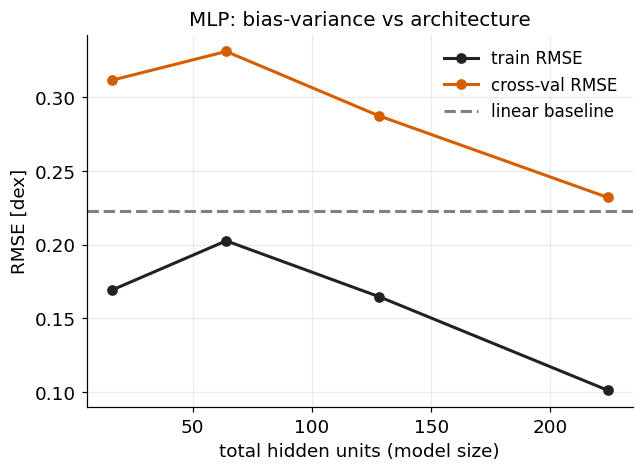

In [7]:
# <- your turn: edit this list of architectures to sweep. (Keep it short — each entry is a few fits.)
architectures = [(16,), (64,), (64, 64), (128, 64, 32)]

train_rmse, cv_rmse = [], []
for hls in architectures:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pipe = make_model("nn", hidden_layer_sizes=hls, max_iter=300)
        # train RMSE: fit on the tuning slice, score on it (will look optimistic)
        pipe.fit(X_tune, y_tune)
        tr = regression_metrics(y_tune, pipe.predict(X_tune))["RMSE"]
        # cross-validated RMSE: honest estimate of unseen-star error (cv=3, scaler refits per fold)
        cv = -cross_val_score(make_model("nn", hidden_layer_sizes=hls, max_iter=300),
                              X_tune, y_tune, cv=3,
                              scoring="neg_root_mean_squared_error", n_jobs=3).mean()
    train_rmse.append(tr); cv_rmse.append(cv)
    log_experiment("nn", {"hidden_layer_sizes": str(hls), "alpha": 1e-3, "stage": "structural"},
                   {"train_rmse": tr, "cv_rmse": cv})
    print(f"  {str(hls):16s} train RMSE {tr:.3f} | CV RMSE {cv:.3f} dex")

# plot the bias-variance curve (x = total hidden units, a simple size proxy)
sizes = [sum(h) for h in architectures]
fig, ax = plt.subplots()
ax.plot(sizes, train_rmse, "o-", color=COLORS["truth"], label="train RMSE")
ax.plot(sizes, cv_rmse,    "o-", color=COLORS["nn"],    label="cross-val RMSE")
ax.axhline(baseline_rmse, ls="--", color="0.5", label="linear baseline")
ax.set_xlabel("total hidden units (model size)"); ax.set_ylabel("RMSE [dex]")
ax.set_title("MLP: bias-variance vs architecture"); ax.legend()
plt.show()

# <- your turn: which architecture has the LOWEST cross-val RMSE? Where does train RMSE keep
#    dropping while CV stops improving (the overfitting end)?

*Caption: the tiny net **underfits** (both curves high). As the net grows, **train RMSE keeps falling** but the **cross-val RMSE** bottoms out and then flattens — past that point you're buying capacity that only helps on the training stars. The bottom of the CV curve is the architecture worth keeping.*

## 3 · Categorical knobs: activation and solver (your turn)

Two knobs here aren't numbers on a scale — they're **choices from a menu**:

- **`activation`** — the non-linearity each unit applies. `"relu"` (a hinge at zero) is the modern
  default; `"tanh"` (a smooth S-curve) sometimes fits smoother targets better.
- **`solver`** — the optimizer that fits the weights. `"adam"` is a robust stochastic gradient method;
  `"lbfgs"` is a batch method that can be more accurate on smaller problems but slower per fit (and it
  ignores `early_stopping`).

For categorical knobs there's no curve to plot — you just **try each option and compare scores in a
small table.** Fix the architecture (use a middling one so each fit is quick) and loop over the menu.

The cell runs as shipped over `activation`. **Your turn:** add `"logistic"` to the `activations` list,
or flip `try_solvers` to compare `adam` vs `lbfgs` too.


In [8]:
# <- your turn: extend the menus you compare.
activations = ["relu", "tanh"]            # <- your turn: add "logistic"
try_solvers  = ["adam"]                    # <- your turn: add "lbfgs" (slower, sometimes more accurate)
fixed_arch   = (64, 64)                     # fix the architecture so we isolate the categorical effect

rows = []
for solver in try_solvers:
    for act in activations:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            cv = -cross_val_score(make_model("nn", hidden_layer_sizes=fixed_arch, activation=act,
                                             solver=solver, max_iter=300),
                                  X_tune, y_tune, cv=3,
                                  scoring="neg_root_mean_squared_error", n_jobs=3).mean()
        rows.append({"activation": act, "solver": solver, "cv_rmse": round(cv, 4)})
        log_experiment("nn", {"hidden_layer_sizes": str(fixed_arch), "activation": act,
                              "solver": solver, "stage": "categorical"}, {"cv_rmse": cv})

cat_table = pd.DataFrame(rows).sort_values("cv_rmse").reset_index(drop=True)
print(cat_table.to_string(index=False))
# <- your turn (read): which activation wins? Did adding lbfgs change the ranking?

activation solver  cv_rmse
      tanh   adam   0.2027
      relu   adam   0.2874


*Caption: a tiny scorecard — no curve, just a ranking. Categorical knobs are exactly what a `GridSearchCV` is built to sweep exhaustively, which is where we go next.*

### See the optimizer work: the loss curve

Every fitted MLP records `loss_curve_` — the training loss at each iteration. Plotting it is the
single best way to *see* whether training **converged** (the curve flattens) or got cut off early (the
curve is still dropping at the end → raise `max_iter`). Here's the default net's curve.


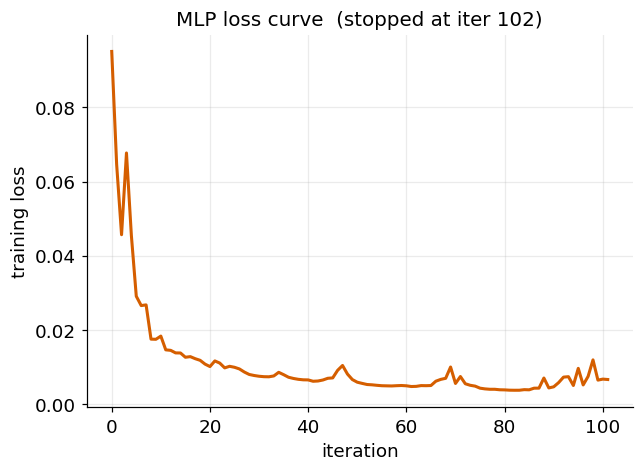

In [9]:
# Plot the loss curve of the default net (fit in section 1). A flattening tail = converged.
mlp = nn0.named_steps["mlpregressor"]
fig, ax = plt.subplots()
ax.plot(mlp.loss_curve_, color=COLORS["nn"])
ax.set_xlabel("iteration"); ax.set_ylabel("training loss")
ax.set_title(f"MLP loss curve  (stopped at iter {mlp.n_iter_})")
plt.show()

# What to look for: a steep early drop that flattens out. If it were still falling at the right edge,
# the model wanted more iterations (raise max_iter); early_stopping usually halts it once it plateaus.

*Caption: the loss falls fast, then flattens — `early_stopping` halted training once the held-out score stopped improving. If your curve is still steeply dropping at the right edge, raise `max_iter`.*

## 4 · Systematic search: GridSearchCV, then RandomizedSearchCV (your turn)

By-hand sweeps build intuition; **automated search** does the bookkeeping. Two tools, two jobs:

- **`GridSearchCV`** tries **every combination** of a small grid. Perfect for a handful of values,
  especially **categorical** ones. It cross-validates each combo (the scaler refits per fold → no
  leakage) and refits the winner for you.
- **`RandomizedSearchCV`** samples random points from **distributions** you specify. When the grid
  would explode (continuous knobs × architecture × categorical), random search finds a good corner for
  a fixed budget of `n_iter` fits.

One sign convention: sklearn *maximizes* its score, so RMSE is reported **negative**
(`neg_root_mean_squared_error`). Flip the sign to read it as an RMSE.

We keep the **executed** searches modest (small grids, `cv=3`, `early_stopping` on, capped `max_iter`)
so they finish in a couple of minutes — but the comments show you exactly how to widen them.

*Reference:*
[GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html#exhaustive-grid-search) ·
[RandomizedSearchCV](https://scikit-learn.org/stable/modules/grid_search.html#randomized-parameter-optimization).


In [10]:
# GridSearchCV: exhaustive over a SMALL grid. We fix the architecture and sweep activation x alpha.
# (4 combos x cv=3 = 12 fits on the tuning slice; fast with early_stopping on.)
grid_pipe = make_model("nn", hidden_layer_sizes=(64, 64), max_iter=300)
param_grid = {
    "mlpregressor__activation": ["relu", "tanh"],     # <- your turn: add "logistic"
    "mlpregressor__alpha":      [1e-4, 1e-2],          # <- your turn: widen to [1e-5,1e-4,1e-3,1e-2,1e-1]
}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid = GridSearchCV(grid_pipe, param_grid, cv=3,
                        scoring="neg_root_mean_squared_error", n_jobs=4)
    grid.fit(X_tune, y_tune)

print("grid best params:", grid.best_params_)
print(f"grid best CV RMSE: {-grid.best_score_:.3f} dex")
log_experiment("nn", {**{k.split('__')[1]: v for k, v in grid.best_params_.items()},
                      "hidden_layer_sizes": "(64, 64)", "stage": "grid_best"},
               {"cv_rmse": -grid.best_score_})

grid best params: {'mlpregressor__activation': 'tanh', 'mlpregressor__alpha': 0.01}
grid best CV RMSE: 0.202 dex


,run,param_hidden_layer_sizes,param_alpha,param_activation,param_solver,param_stage,test_rmse,test_R2,train_rmse,cv_rmse,param_learning_rate_init
0,1,"(64, 64)",0.001,relu,adam,default,0.165993,0.767592,NaN,NaN,NaN
1,2,"(16,)",0.001,NaN,NaN,structural,NaN,NaN,0.143821,0.189262,NaN
2,3,"(64,)",0.001,NaN,NaN,structural,NaN,NaN,0.115367,0.213921,NaN
3,4,"(64, 64)",0.001,NaN,NaN,structural,NaN,NaN,0.108562,0.219984,NaN
4,5,"(128, 64, 32)",0.001,NaN,NaN,structural,NaN,NaN,0.086064,0.184557,NaN
...,...,...,...,...,...,...,...,...,...,...,...
86,87,"(64, 64)",0.001,NaN,NaN,structural,NaN,NaN,0.164818,0.287406,NaN
87,88,"(128, 64, 32)",0.001,NaN,NaN,structural,NaN,NaN,0.101296,0.232032,NaN
88,89,"(64, 64)",NaN,relu,adam,categorical,NaN,NaN,NaN,0.287406,NaN
89,90,"(64, 64)",NaN,tanh,adam,categorical,NaN,NaN,NaN,0.202730,NaN


*Caption: `GridSearchCV` tried every activation × alpha combo and reports the best. For a few categorical knobs this is exactly the right tool. But add the architecture and `learning_rate_init` and the grid balloons — that's the job for random search below.*

### RandomizedSearchCV — the big space

Now let random search roam over **all three knob kinds at once**: architecture (structural),
`alpha` + `learning_rate_init` (continuous, sampled log-uniformly), and `activation` (categorical).
To keep it fast we sample only a handful of points (`n_iter`) and search on a **subsample** of the
training stars, then refit the single best configuration on the **full** training set. Widen `n_iter`
and drop the subsample for a more thorough hunt.


In [11]:
# RandomizedSearchCV over the FULL knob space. We search on the small TUNING SLICE for speed,
# then refit the winning config on ALL of train below.
X_sub, y_sub = X_tune, y_tune                              # <- your turn: search on more stars (slower)

search_pipe = make_model("nn", max_iter=250)
param_dist = {
    "mlpregressor__hidden_layer_sizes": [(64, 64), (128, 64), (128, 64, 32)],
    "mlpregressor__activation":         ["relu", "tanh"],
    "mlpregressor__alpha":              loguniform(1e-5, 1e-1),       # continuous, log-uniform
    "mlpregressor__learning_rate_init": loguniform(1e-4, 1e-2),       # continuous, log-uniform
}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    rsearch = RandomizedSearchCV(search_pipe, param_dist, n_iter=10,  # <- your turn: raise n_iter (slower)
                                 cv=3, scoring="neg_root_mean_squared_error",
                                 n_jobs=4, random_state=0)
    rsearch.fit(X_sub, y_sub)

best = rsearch.best_params_
print("random-search best params:")
for k, v in best.items():
    print(f"   {k.split('__')[1]:20s} {v}")
print(f"random-search best CV RMSE (on subsample): {-rsearch.best_score_:.3f} dex")
log_experiment("nn", {**{k.split('__')[1]: (round(v, 5) if isinstance(v, float) else v)
                         for k, v in best.items()}, "stage": "random_best"},
               {"cv_rmse": -rsearch.best_score_})

random-search best params:
   activation           tanh
   alpha                0.030223797682839164
   hidden_layer_sizes   (64, 64)
   learning_rate_init   0.00399780405315362
random-search best CV RMSE (on subsample): 0.184 dex


,run,param_hidden_layer_sizes,param_alpha,param_activation,param_solver,param_stage,test_rmse,test_R2,train_rmse,cv_rmse,param_learning_rate_init
0,1,"(64, 64)",0.00100,relu,adam,default,0.165993,0.767592,NaN,NaN,NaN
1,2,"(16,)",0.00100,NaN,NaN,structural,NaN,NaN,0.143821,0.189262,NaN
2,3,"(64,)",0.00100,NaN,NaN,structural,NaN,NaN,0.115367,0.213921,NaN
3,4,"(64, 64)",0.00100,NaN,NaN,structural,NaN,NaN,0.108562,0.219984,NaN
4,5,"(128, 64, 32)",0.00100,NaN,NaN,structural,NaN,NaN,0.086064,0.184557,NaN
...,...,...,...,...,...,...,...,...,...,...,...
87,88,"(128, 64, 32)",0.00100,NaN,NaN,structural,NaN,NaN,0.101296,0.232032,NaN
88,89,"(64, 64)",NaN,relu,adam,categorical,NaN,NaN,NaN,0.287406,NaN
89,90,"(64, 64)",NaN,tanh,adam,categorical,NaN,NaN,NaN,0.202730,NaN
90,91,"(64, 64)",0.01000,tanh,NaN,grid_best,NaN,NaN,NaN,0.201738,NaN


*Caption: random search wandered the whole space — architecture, activation, and two continuous knobs — and found a good corner in just a few fits. A `tanh` net with a moderate `alpha` tends to come out on top. We refit this exact config on all the training stars next, then score it on the untouched test set.*

## 5 · Your tuned model — lock it in, then map where it works

Time to commit. We take the **best configuration** the search found, rebuild it cleanly with
`make_model("nn", ...)`, fit it on the **full** training set, and score it **once** on the untouched
**test** set — the honest number you report.

Then we do what a single RMSE can't: **map where the model is reliable.** Same two moves as the common
notebook's baseline, now on *your* tuned network:

1. color each test star by its `|[Fe/H] error|` on the **Kiel plane** (`Teff`–`log g`);
2. bin the error by **`log g`** and by **`[Fe/H]`** to read off the hard regions numerically.

Watch for the corrected failure-mode story: the hardest stars are **metal-poor** ones and **luminous
(low-`log g`) giants** — the sparse, information-starved corners — *not* hot stars.


In [12]:
# Build the tuned model from the random-search winner. (You could also paste your favourite params
# from the experiment log by hand — that's what the dict below does for you automatically.)
best_arch = best["mlpregressor__hidden_layer_sizes"]
best_act  = best["mlpregressor__activation"]
best_alpha = best["mlpregressor__alpha"]
best_lri   = best["mlpregressor__learning_rate_init"]

# <- your turn: override any of these with a setting you liked better from your own runs.
tuned_nn = make_model("nn", hidden_layer_sizes=best_arch, activation=best_act,
                      alpha=best_alpha, learning_rate_init=best_lri, max_iter=400)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    tuned_nn.fit(sp["X_train"], y_train)            # refit on the FULL training set

nn_test_pred = tuned_nn.predict(sp["X_test"])
tuned_metrics = regression_metrics(y_test, nn_test_pred)
print(f"TUNED MLP  test RMSE = {tuned_metrics['RMSE']:.3f} dex   (baseline {baseline_rmse:.3f}, "
      f"default {m0['RMSE']:.3f})")
log_experiment("nn", {"hidden_layer_sizes": str(best_arch), "activation": best_act,
                      "alpha": round(float(best_alpha), 5), "stage": "tuned_final"},
               {"test_rmse": tuned_metrics["RMSE"], "test_R2": tuned_metrics["R2"]})

TUNED MLP  test RMSE = 0.146 dex   (baseline 0.223, default 0.166)


,run,param_hidden_layer_sizes,param_alpha,param_activation,param_solver,param_stage,test_rmse,test_R2,train_rmse,cv_rmse,param_learning_rate_init
0,1,"(64, 64)",0.00100,relu,adam,default,0.165993,0.767592,NaN,NaN,NaN
1,2,"(16,)",0.00100,NaN,NaN,structural,NaN,NaN,0.143821,0.189262,NaN
2,3,"(64,)",0.00100,NaN,NaN,structural,NaN,NaN,0.115367,0.213921,NaN
3,4,"(64, 64)",0.00100,NaN,NaN,structural,NaN,NaN,0.108562,0.219984,NaN
4,5,"(128, 64, 32)",0.00100,NaN,NaN,structural,NaN,NaN,0.086064,0.184557,NaN
...,...,...,...,...,...,...,...,...,...,...,...
88,89,"(64, 64)",NaN,relu,adam,categorical,NaN,NaN,NaN,0.287406,NaN
89,90,"(64, 64)",NaN,tanh,adam,categorical,NaN,NaN,NaN,0.202730,NaN
90,91,"(64, 64)",0.01000,tanh,NaN,grid_best,NaN,NaN,NaN,0.201738,NaN
91,92,"(64, 64)",0.03022,tanh,NaN,random_best,NaN,NaN,NaN,0.184137,0.004


*Caption: your tuned network's honest test score, next to the baseline and the default. The tuning earned real ground — and the next plots show *where*.*

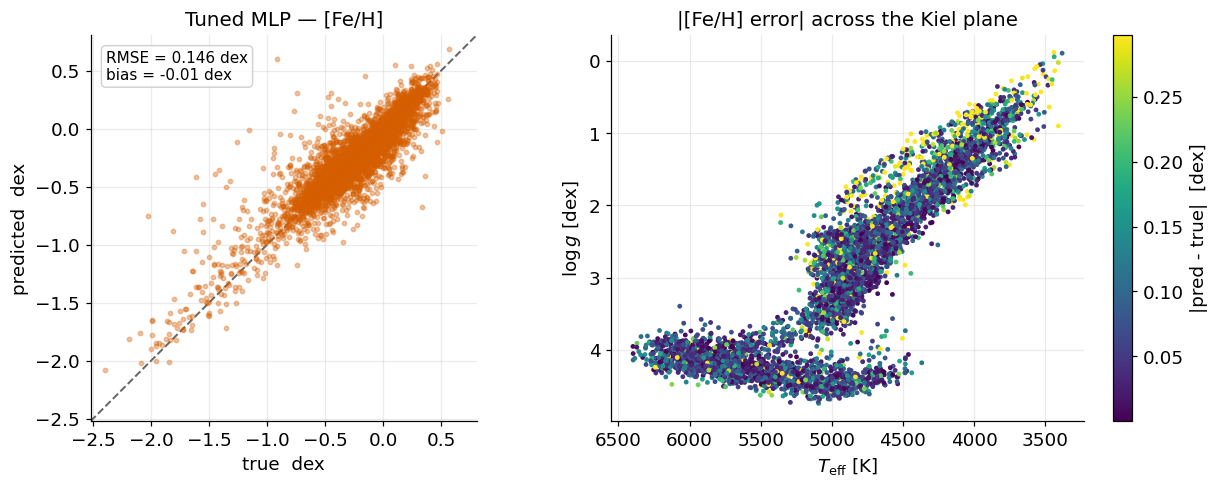

In [13]:
# Error map: |[Fe/H] error| per TEST star on the Kiel plane (Teff vs log g).
abs_err = np.abs(nn_test_pred - y_test)
teff = sp["y_test"]["Teff"].to_numpy()
logg = sp["y_test"]["logg"].to_numpy()
feh  = sp["y_test"]["FeH"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# Left: pred vs true. Right: the Kiel error map.
plot_pred_vs_true(y_test, nn_test_pred, ax=axes[0],
                  color=COLORS["nn"], title="Tuned MLP — [Fe/H]", units=" dex")
sc = axes[1].scatter(teff, logg, c=abs_err, s=10, cmap="viridis",
                     vmax=np.quantile(abs_err, 0.95))     # clip color so a few big errors don't dominate
axes[1].invert_xaxis(); axes[1].invert_yaxis()            # Kiel convention: hot left, giants top
axes[1].set_xlabel(r"$T_\mathrm{eff}$ [K]"); axes[1].set_ylabel(r"$\log g$ [dex]")
axes[1].set_title("|[Fe/H] error| across the Kiel plane")
fig.colorbar(sc, ax=axes[1], label="|pred - true|  [dex]")
plt.tight_layout()
savefig("nb2c_nn_errormap.png")
plt.show()

*Caption: the error isn't uniform across the plane. Don't eyeball it alone — the next cell bins the error by `log g` and by `[Fe/H]` so you can read off exactly which stars are hard.*

In [14]:
# Quantify the discovery: mean |error| in terciles of log g and of [Fe/H].
def binned_error(values, name, n=3):
    edges = np.quantile(values, np.linspace(0, 1, n + 1)); edges[-1] += 1e-9
    print(f"mean |[Fe/H] error| by {name}:")
    for i in range(n):
        m = (values >= edges[i]) & (values < edges[i + 1])
        print(f"  {name} in [{edges[i]:7.2f}, {edges[i+1]:7.2f}] : "
              f"{abs_err[m].mean():.3f} dex   (n={m.sum()})")

binned_error(logg, "log g")   # low log g = luminous GIANTS; high log g = compact DWARFS
binned_error(feh,  "[Fe/H]")  # low [Fe/H] = METAL-POOR stars

# <- your turn: which tercile is hardest — the giants (low log g) or the metal-poor stars? Try the
#    SIGNED error (nn_test_pred - y_test) instead of |error|: is the net biased high or low there?

mean |[Fe/H] error| by log g:
  log g in [  -0.12,    2.39] : 0.122 dex   (n=2000)
  log g in [   2.39,    3.47] : 0.087 dex   (n=2000)
  log g in [   3.47,    4.74] : 0.079 dex   (n=2000)
mean |[Fe/H] error| by [Fe/H]:
  [Fe/H] in [  -2.40,   -0.31] : 0.122 dex   (n=2000)
  [Fe/H] in [  -0.31,   -0.05] : 0.083 dex   (n=2000)
  [Fe/H] in [  -0.05,    0.57] : 0.084 dex   (n=2000)


*Caption: read the two tables together. The error is largest for the **lowest-`log g`** stars (luminous giants) and the **lowest-`[Fe/H]`** stars (metal-poor) — the sparse, information-starved corners — and smallest for metal-rich dwarfs. That uneven, *conditional* error is exactly the problem next week's uncertainty work tackles, now on your own tuned model.*

## 6 · Interpret your model with SHAP (stretch)

A linear model hands you its coefficients — you can read off exactly how each coefficient pushes the
prediction. A neural network hides that inside its weights. **SHAP** (SHapley Additive exPlanations)
recovers it: for any prediction, it attributes the result back to the input features, telling you how
much each of the 110 coefficients pushed *this* star's `[Fe/H]` up or down. It's the library version of
the hand-computed effects you saw in Notebook 1, now for a model you can't read directly.

The honest catch for an MLP: there's **no fast exact explainer** (unlike random forests). SHAP must
probe the model with many perturbed inputs, which is **slow** — so we **cap it hard**: a small
**background** of ~100 training stars and only ~50 test stars to explain. That's enough to see the
pattern; widen both for a smoother picture (and a longer wait).


PermutationExplainer explainer:  30%|███       | 15/50 [00:00<?, ?it/s]

PermutationExplainer explainer:  34%|███▍      | 17/50 [00:10<00:04,  7.55it/s]

PermutationExplainer explainer:  36%|███▌      | 18/50 [00:10<00:06,  4.69it/s]

PermutationExplainer explainer:  38%|███▊      | 19/50 [00:10<00:07,  4.39it/s]

PermutationExplainer explainer:  40%|████      | 20/50 [00:11<00:07,  4.07it/s]

...

PermutationExplainer explainer:  98%|█████████▊| 49/50 [00:19<00:00,  3.75it/s]

PermutationExplainer explainer: 100%|██████████| 50/50 [00:19<00:00,  3.71it/s]

PermutationExplainer explainer: 51it [00:19,  3.70it/s]                        

PermutationExplainer explainer: 51it [00:19,  1.84it/s]

SHAP values shape: (50, 110) (stars x 110 coefficients)


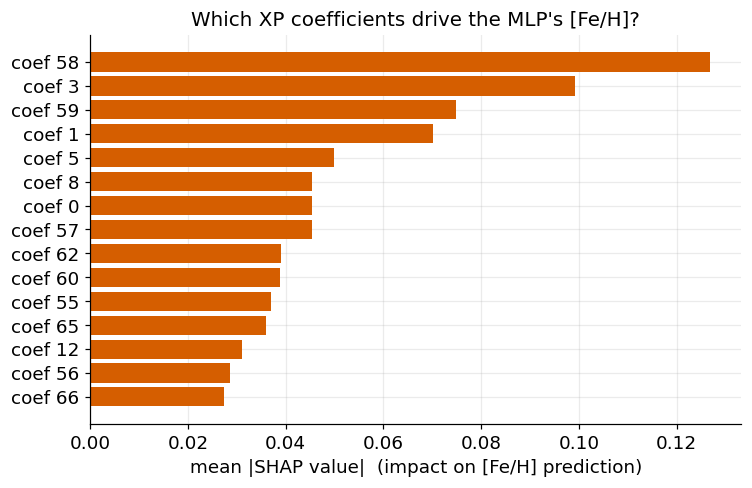

In [15]:
import shap

# Small, capped SHAP run (this can take ~1-2 minutes even capped — that's expected for an MLP).
bg     = shap.utils.sample(sp["X_train"], 100, random_state=0)   # ~100-row background (the "baseline")
X_expl = sp["X_test"][:50]                                       # explain ~50 test stars

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    explainer = shap.Explainer(tuned_nn.predict, bg)            # model-agnostic; probes .predict
    shap_values = explainer(X_expl)

print("SHAP values shape:", shap_values.values.shape, "(stars x 110 coefficients)")

# Mean |SHAP| per coefficient = a global importance ranking. Show the top 15 coefficients.
mean_abs = np.abs(shap_values.values).mean(axis=0)
order = np.argsort(mean_abs)[::-1][:15]
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh([f"coef {i}" for i in order][::-1], mean_abs[order][::-1], color=COLORS["nn"])
ax.set_xlabel("mean |SHAP value|  (impact on [Fe/H] prediction)")
ax.set_title("Which XP coefficients drive the MLP's [Fe/H]?")
plt.tight_layout()
savefig("nb2c_nn_shap_importance.png")
plt.show()

*Caption: a handful of the 110 coefficients carry most of the `[Fe/H]` signal — the ones tied to the metal lines. SHAP found them without ever seeing the model's internals, just by probing its predictions.*

## 7 · Save your work — model, predictions, and the experiment log

Three things travel forward from this lab, using the project helpers:

1. **`save_model(tuned_nn, "nn")`** → `models/nn.joblib`. The **exact tuned model**, so Notebook 3 can
   load it and quantify *the model you tuned* — never a silent refit. A trained model is an experiment
   result; persist it.
2. **`save_outputs("nn_preds.npz", ...)`** → predictions and truths on **both** the calibration and
   test splits, in the fixed schema the later notebooks read:

   > `outputs/nn_preds.npz` with keys `y_cal_true, y_cal_pred, y_test_true, y_test_pred`.

3. **`outputs/nn_experiments.csv`** — already being written by every `log_experiment(...)` call. Print
   it to see your whole run history, the bare-bones version of what **MLflow** or **Weights & Biases**
   do for real teams: a durable record of *what did I try, and how did it score?*

The model string is **`"nn"`** (not `"mlp"`) — that's the contract.


In [16]:
# 1) Save the fitted tuned model (NB3 loads THIS exact object — no refit).
path = save_model(tuned_nn, "nn")
print("wrote", path)

# 2) Save predictions on BOTH cal and test (the NB2->NB3->NB4 contract).
save_outputs(
    "nn_preds.npz",
    y_cal_true =y_cal,
    y_cal_pred =tuned_nn.predict(sp["X_cal"]),
    y_test_true=y_test,
    y_test_pred=tuned_nn.predict(sp["X_test"]),
)
print("wrote outputs/nn_preds.npz")

# 3) Sanity-check the schema, then show the experiment log.
chk = load_outputs("nn_preds.npz")
print("preds keys:", sorted(chk.keys()), "| test preds shape:", chk["y_test_pred"].shape)

print("\n=== your experiment log (outputs/nn_experiments.csv) ===")
full_log = pd.read_csv(os.path.join(OUTPUTS_DIR, "nn_experiments.csv"))
print(full_log.to_string(index=False))

wrote /mnt/c/Users/joshs/Dropbox/GitHub/utssrp-2026/models/nn.joblib


wrote outputs/nn_preds.npz
preds keys: ['y_cal_pred', 'y_cal_true', 'y_test_pred', 'y_test_true'] | test preds shape: (6000,)

=== your experiment log (outputs/nn_experiments.csv) ===
 run param_hidden_layer_sizes  param_alpha param_activation param_solver param_stage  test_rmse  test_R2  train_rmse  cv_rmse  param_learning_rate_init
   1                 (64, 64)      0.00100             relu         adam     default   0.165993 0.767592         NaN      NaN                       NaN
   2                    (16,)      0.00100              NaN          NaN  structural        NaN      NaN    0.143821 0.189262                       NaN
   3                    (64,)      0.00100              NaN          NaN  structural        NaN      NaN    0.115367 0.213921                       NaN
   4                 (64, 64)      0.00100              NaN          NaN  structural        NaN      NaN    0.108562 0.219984                       NaN
   5            (128, 64, 32)      0.00100              

*Caption: your tuned network is saved three ways — the model, its predictions, and the full run log. Notebooks 3 and 4 pick up `models/nn.joblib` and `outputs/nn_preds.npz` from here.*

## Wrap-up · What you built, and what's next

You ran a full tuning lab on your own model — the neural network. You **read the docstring**, **swept
the architecture by hand** and watched the bias–variance curve, compared **categorical** knobs, and
drove **`GridSearchCV`** and **`RandomizedSearchCV`** over the whole space — **logging every run** and
**saving** your best model. Your tuned MLP beats the linear baseline by a comfortable margin.

But the map told the deeper story: the errors aren't uniform. They pile up on **metal-poor stars and
luminous (low-`log g`) giants** — the sparse, information-starved corners — so the error *size* changes
across the data. A single RMSE can't express that, and tuning didn't remove it.

- **Notebook 3 (your version, `03c_uncertainty_neural_net`)** turns your point predictions into
  **intervals** and asks whether they're *honest*. Your model's native uncertainty comes from a small
  **ensemble** of nets with different random seeds — the spread of their predictions. You'll find the
  giants and metal-poor stars under-covered.
- **Notebook 4** makes the guarantee *rigorous* with **conformal prediction**, then shows where the
  guarantee still strains.

Your saved `outputs/nn_preds.npz` and `models/nn.joblib` are the inputs to both. Bring your tuned RMSE,
your error map, and one sentence — "the hard region is …" — to the debrief.

---

### Further reading

- **scikit-learn — `MLPRegressor` (API):**
  https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html —
  `hidden_layer_sizes`, `alpha`, `learning_rate_init`, `activation`, `solver`, `early_stopping`,
  `loss_curve_`, `n_iter_`.
- **scikit-learn — Neural network models (user guide):**
  https://scikit-learn.org/stable/modules/neural_networks_supervised.html — how the MLP trains, and
  why scaling the inputs matters.
- **scikit-learn — Tuning hyper-parameters (Grid vs. Randomized search):**
  https://scikit-learn.org/stable/modules/grid_search.html — when to use exhaustive vs. random search.
- **scikit-learn — Cross-validation:**
  https://scikit-learn.org/stable/modules/cross_validation.html — the honest way to score a setting.
- **SHAP — documentation:**
  https://shap.readthedocs.io/en/latest/ — model-agnostic feature attributions; see `shap.Explainer`
  and the beeswarm plot.
- **A Unified Approach to Interpreting Model Predictions — Lundberg & Lee (2017), the SHAP paper:**
  https://arxiv.org/abs/1705.07874
- **Experiment tracking, what real teams use — MLflow:** https://mlflow.org/ ·
  **Weights & Biases:** https://wandb.ai/ — durable, comparable records of every run (our
  `log_experiment` is the bare-bones version).
- **The paper behind the data — Laroche & Speagle 2025 (arXiv:2404.07316):**
  https://arxiv.org/abs/2404.07316
